In [1]:
import pandas as pd
import numpy as np


# 1. Load the CSV file
df = pd.read_csv('NORS_20251104.csv')

print(df.info())

# 1. Clean the string column by removing commas
df['Illnesses'] = df['Illnesses'].astype(str).str.replace(',', '', regex=False)

# 2. Convert to numeric (float), coercing any remaining non-numeric values to NaN
# 'errors='coerce' is crucial for handling mixed types and non-numeric strings
df['Illnesses'] = pd.to_numeric(df['Illnesses'], errors='coerce')
df['Illnesses'] = df['Illnesses'].astype('int64')
# Get the actual list of illnesses states
unique_illnesses_list = df['Illnesses'].unique()

# The list of columns you want to modify
features_to_fill = ['Illnesses', 'Hospitalizations', 'Deaths']

# Replace NaNs with 0 only in the specified columns
df[features_to_fill] = df[features_to_fill].fillna(0)

print(df.info())
print(df.describe())

hosp_above_zero = df[df['Hospitalizations'] > 0]
print("number of rows that have hospitalizations above 0:", len(hosp_above_zero))
death_above_zero = df[df['Deaths'] > 0]
print("number of rows that have death above 0:", len(death_above_zero))

df.head(100)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 66713 entries, 0 to 66712
Data columns (total 19 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Year                          66713 non-null  int64  
 1   Month                         66713 non-null  int64  
 2   State                         66713 non-null  object 
 3   Primary Mode                  66713 non-null  object 
 4   Etiology                      50375 non-null  object 
 5   Serotype or Genotype          16470 non-null  object 
 6   Etiology Status               50375 non-null  object 
 7   Setting                       60804 non-null  object 
 8   Illnesses                     66713 non-null  object 
 9   Hospitalizations              58155 non-null  float64
 10  Info On Hospitalizations      58480 non-null  object 
 11  Deaths                        58785 non-null  float64
 12  Info On Deaths                58463 non-null  object 
 13  F

C:\Users\jared\AppData\Local\Temp\ipykernel_26876\3382388245.py:6: DtypeWarning: Columns (8,10,12) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('NORS_20251104.csv')


,Year,Month,State,Primary Mode,Etiology,Serotype or Genotype,Etiology Status,Setting,Illnesses,Hospitalizations,Info On Hospitalizations,Deaths,Info On Deaths,Food Vehicle,Food Contaminated Ingredient,IFSAC Category,Water Exposure,Water Type,Animal Type
0,1971,2,California,Water,Copper,NaN,Confirmed,Restaurant,2,0.0,NaN,0.0,NaN,NaN,NaN,NaN,Drinking water,Community,NaN
1,1971,6,Arkansas,Water,Hepatitis A,NaN,Confirmed,Store,98,0.0,NaN,0.0,NaN,NaN,NaN,NaN,Drinking water,Other,NaN
2,1971,6,Missouri,Water,Unknown,NaN,Suspected,Subdivision/Neighborhood,2,0.0,NaN,0.0,NaN,NaN,NaN,NaN,Drinking water,Community,NaN
3,1971,6,Alabama,Water,Selenium,NaN,Confirmed,Unknown,3,0.0,NaN,0.0,NaN,NaN,NaN,NaN,Drinking water,Individual/Private,NaN
4,1971,6,Vermont,Water,Unknown,NaN,Suspected,Community/municipality,3,0.0,NaN,0.0,NaN,NaN,NaN,NaN,Drinking water,Community,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,1974,9,Utah,Water,Giardia duodenalis,NaN,Confirmed,Backcountry/wilderness area,34,0.0,NaN,0.0,NaN,NaN,NaN,NaN,Other/Environmental water,NaN,NaN
96,1974,9,Pennsylvania,Water,Legionella pneumophila,unknown,Confirmed,Hotel/motel,11,0.0,NaN,0.0,NaN,NaN,NaN,NaN,Undetermined water,NaN,NaN
97,1974,9,New York,Water,Chromium,NaN,Confirmed,Office/indoor workplace,20,0.0,NaN,0.0,NaN,NaN,NaN,NaN,Drinking water,Community,NaN
98,1974,10,Pennsylvania,Water,Unknown,NaN,Suspected,Restaurant,18,0.0,NaN,0.0,NaN,NaN,NaN,NaN,Drinking water,Other,NaN


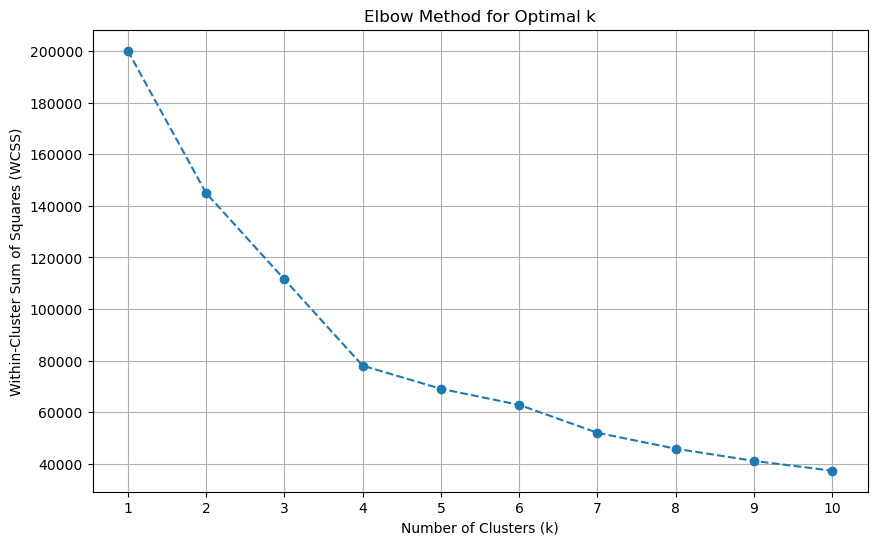

WCSS values for k=1 to 10:
1     200106.000000
2     144989.328447
3     111543.949578
4      78079.535024
5      69103.754065
6      62884.599798
7      52053.820854
8      45890.959958
9      41165.666338
10     37363.349755
dtype: float64


In [8]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# Create the new feature: Hospitalizations per Illness
df['hosp_per_ill'] = df['Hospitalizations'].divide(df['Illnesses']).fillna(0)

# Create the new feature: Deaths per Illness
df['death_per_ill'] = df['Deaths'].divide(df['Illnesses']).fillna(0)

df_no_outlier = df.drop(index=[871, 199, 119, 202, 317, 512, 651, 674, 814, 947, 13225])

# Your specified features
features = ['Year', 'Month', 'Illnesses']
X = df_no_outlier[features]

# 1. Z-transformation (Standard Scaling)
# Standard Scaler performs the Z-transformation: (x - mean) / standard deviation
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 2. Elbow Method with WCSS (Inertia)
wcss = []
k_range = range(1, 11)
random_seed = 511 # Set seed for reproducibility, as requested

for i in k_range:
    # Initialize K-Means with the specified seed and k value
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=random_seed, n_init='auto')
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_) # .inertia_ is the WCSS

# 3. Plotting the results
plt.figure(figsize=(10, 6))
plt.plot(k_range, wcss, marker='o', linestyle='--')
plt.title('Elbow Method for Optimal k')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Within-Cluster Sum of Squares (WCSS)')
plt.grid(True)
plt.xticks(k_range)
plt.show()

# Optional: Print WCSS values to help with elbow determination
print("WCSS values for k=1 to 10:")
print(pd.Series(wcss, index=k_range))

In [9]:
# Define the k values you want to test
k_values_to_test = [2, 3, 4, 5, 6]
random_seed = 511 # Keep the seed for reproducibility

print("Fitting K-Means models for k=2-15")
print("-" * 40)

for k in k_values_to_test:
    # 1. Initialize the K-Means model
    kmeans_k = KMeans(
        n_clusters=k,
        init='k-means++',
        random_state=random_seed,
        n_init='auto'
    )

    # 2. Fit and predict the cluster labels
    # Assign labels to a new column specific to that k (e.g., 'Cluster_k3')
    column_name = f'Cluster_k{k}'
    df_no_outlier[column_name] = kmeans_k.fit_predict(X_scaled)

    # 3. Print the results for this k
    print(f"\nCluster Sizes for k={k}:")
    print(df_no_outlier[column_name].value_counts())
    print("-" * 40)



Fitting K-Means models for k=2-15
----------------------------------------

Cluster Sizes for k=2:
Cluster_k2
0    38678
1    28024
Name: count, dtype: int64
----------------------------------------

Cluster Sizes for k=3:
Cluster_k3
2    33953
1    19355
0    13394
Name: count, dtype: int64
----------------------------------------

Cluster Sizes for k=4:
Cluster_k4
2    33956
1    19364
3    13276
0      106
Name: count, dtype: int64
----------------------------------------

Cluster Sizes for k=5:
Cluster_k5
2    21162
1    18611
0    16711
3    10117
4      101
Name: count, dtype: int64
----------------------------------------

Cluster Sizes for k=6:
Cluster_k6
2    21681
1    17835
0    16031
3    10071
5      990
4       94
Name: count, dtype: int64
----------------------------------------


In [7]:
# The dataframe 'df' already has the 'Cluster_k3' column added from your previous code
ten_point_cluster = df_no_outlier[df_no_outlier['Cluster_k4'] == 3]

print("ten data points in the outlier cluster:")
print(ten_point_cluster)

ten data points in the outlier cluster:
       Year  Month         State Primary Mode  \
99     1974     11      New York        Water   
119    1975      8  Pennsylvania        Water   
202    1978      3      Colorado        Water   
317    1980      6         Texas        Water   
512    1983      6  Pennsylvania        Water   
651    1987      1       Georgia        Water   
674    1987      9    Multistate        Water   
814    1991      8   Puerto Rico        Water   
947    1995      7       Georgia        Water   
13225  2007      5          Utah        Water   

                                                Etiology Serotype or Genotype  \
99                                    Giardia duodenalis                  NaN   
119                                              Unknown                  NaN   
202                                   Giardia duodenalis                  NaN   
317                                              Unknown                  NaN   
512            

Generating plots for k=3 using existing column: Cluster_k3...


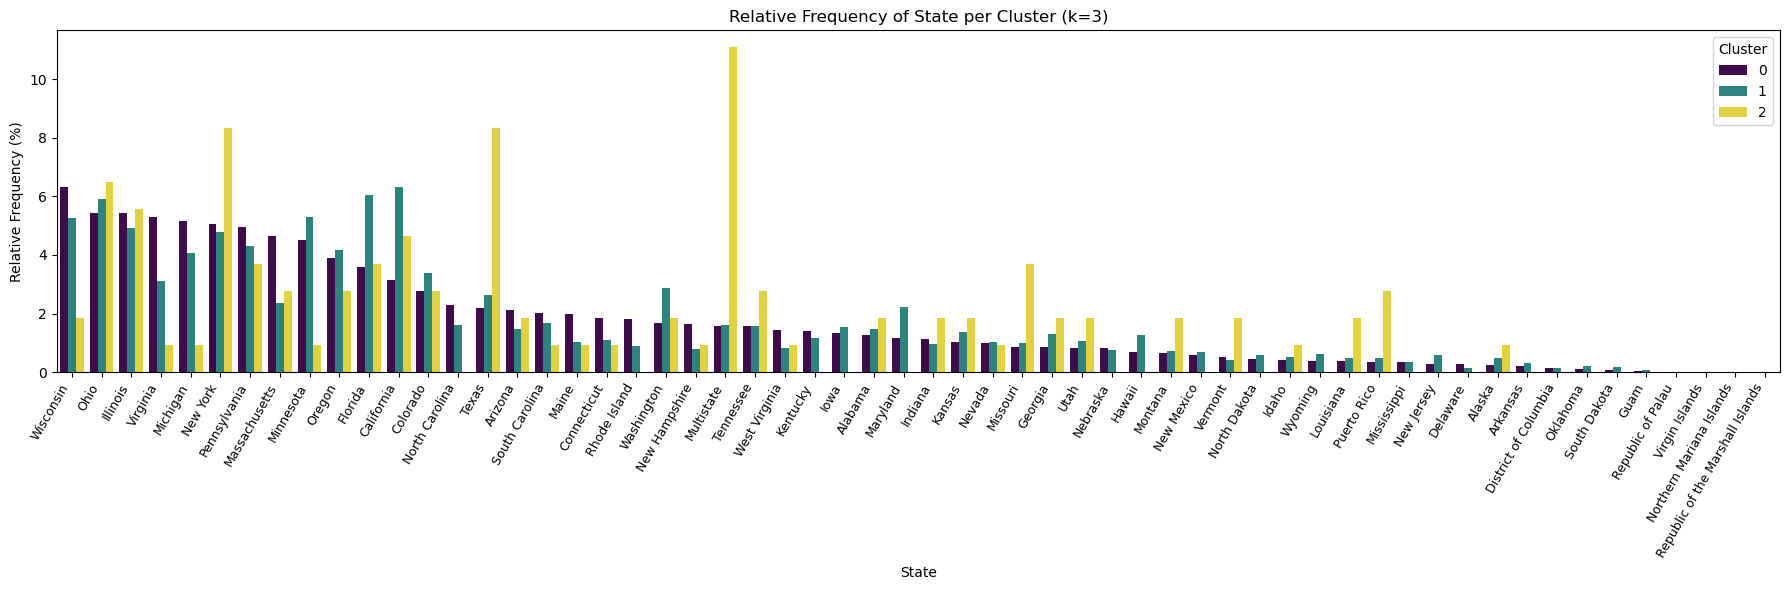

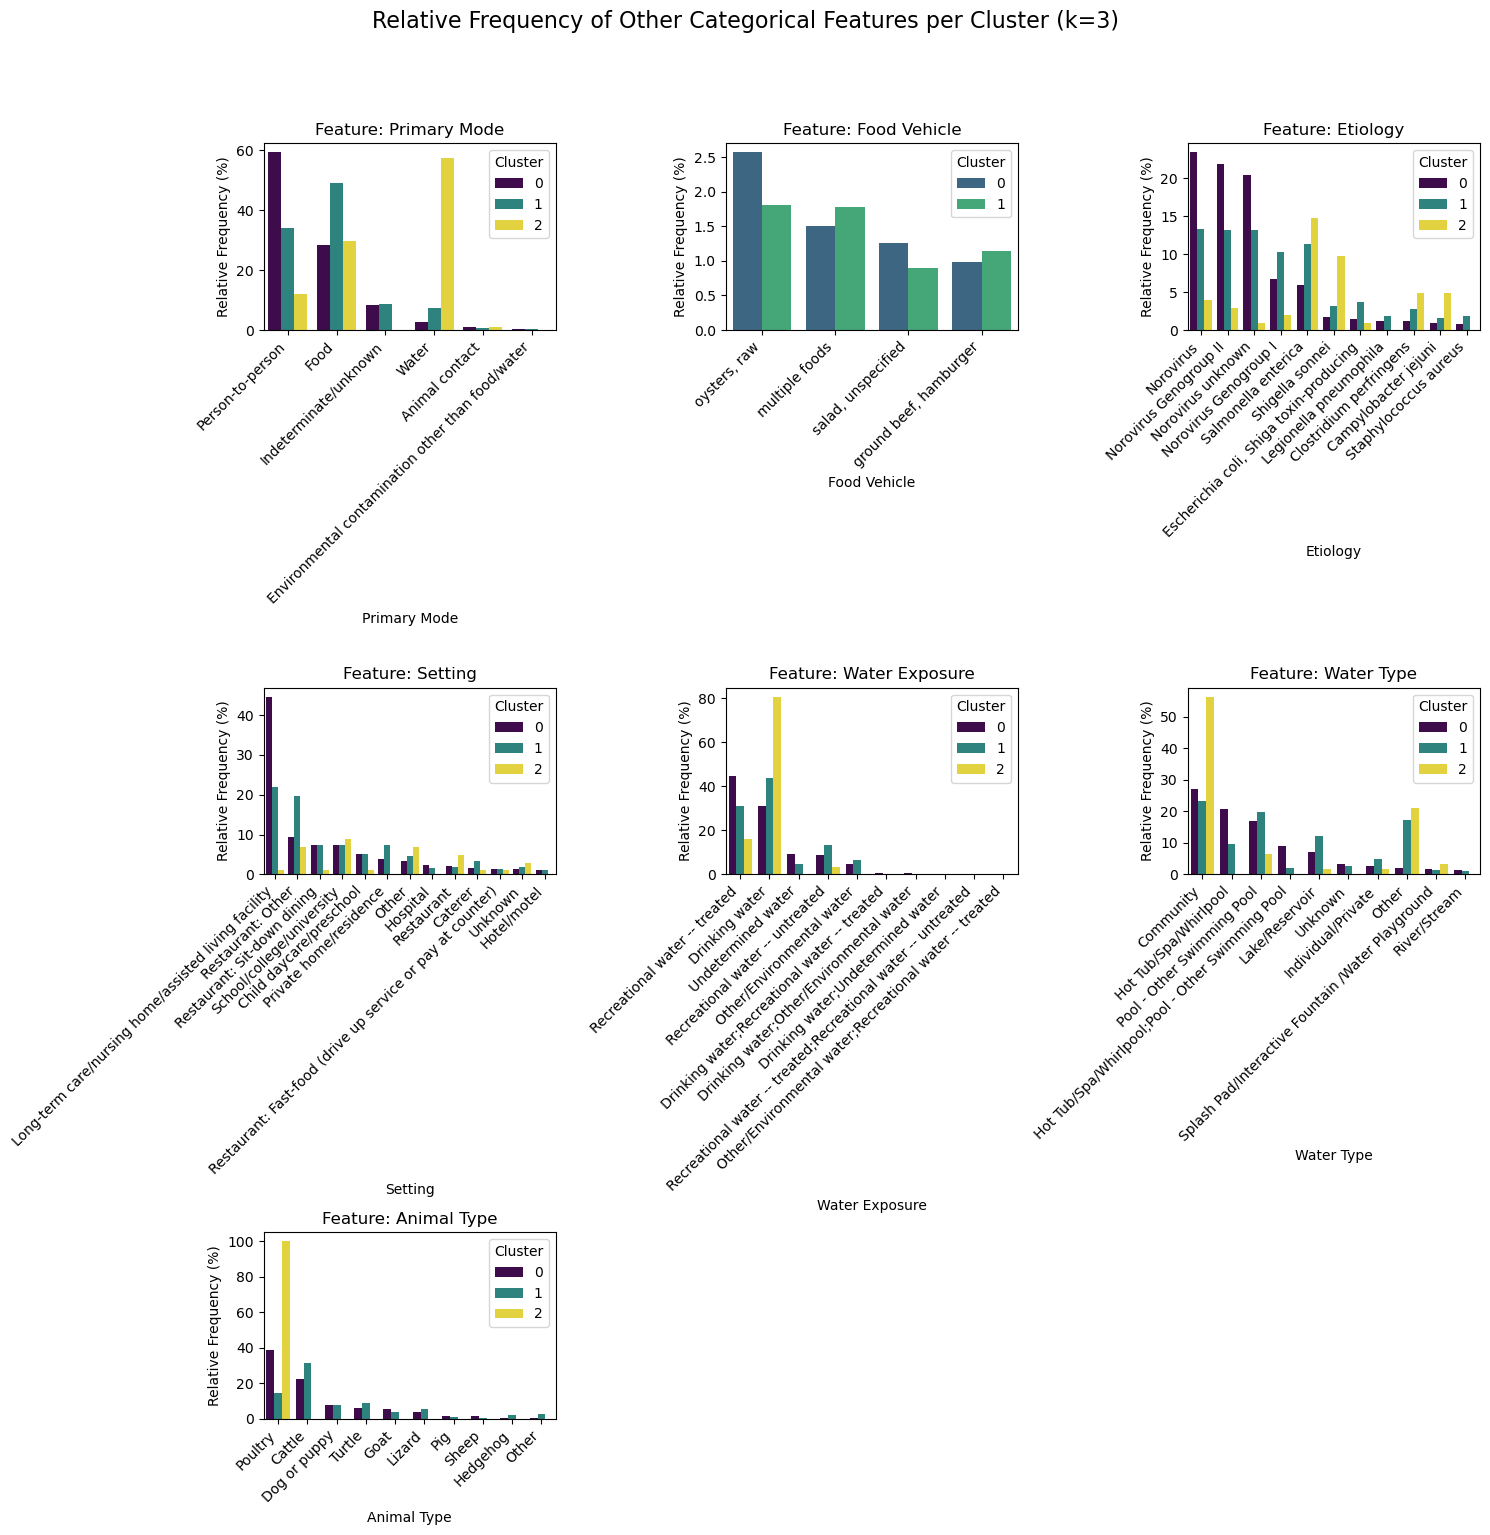

In [17]:
import seaborn as sns

# --- 1. Define the Function (State Plotting Separated) ---
def plot_cluster_relative_frequencies(df_to_plot, cluster_column_name, categorical_features, df_for_nunique):
    """
    Generates bar plots showing the relative frequency of categorical features
    within each cluster, filtering categories less than 1% for 'Animal Type'
    and 'Water Type', and plotting 'State' separately.
    """
    # NOTE: num_clusters is derived from the existing column in the DataFrame
    num_clusters = df_for_nunique[cluster_column_name].nunique()
    
    # --- 1a. Plot the 'State' Feature Separately (Large Plot) ---
    state_feature = 'State'
    plt.figure(figsize=(18, 6)) # Dedicated large figure for State

    # Calculate proportions for State
    proportions_state = df_to_plot.groupby(cluster_column_name)[state_feature].value_counts(normalize=True).mul(100).rename('Percent').reset_index()

    sns.barplot(
        x=state_feature, 
        y='Percent', 
        hue=cluster_column_name, 
        data=proportions_state,
        palette='viridis'
    )
    plt.title(f'Relative Frequency of {state_feature} per Cluster (k={num_clusters})')
    plt.ylabel('Relative Frequency (%)')
    plt.xticks(rotation=60, ha='right', fontsize=9) # Increase rotation for readability
    plt.legend(title='Cluster')
    plt.tight_layout()
    plt.show()

    # --- 1b. Plot the Remaining Features in a Grid ---
    remaining_features = [f for f in categorical_features if f != state_feature]
    n_features = len(remaining_features)
    n_cols = 3 
    n_rows = (n_features + n_cols - 1) // n_cols

    plt.figure(figsize=(n_cols * 5, n_rows * 5))
    plt.suptitle(f'Relative Frequency of Other Categorical Features per Cluster (k={num_clusters})', 
                 fontsize=16, y=1.02)
    
    # Iterate through each remaining categorical feature
    for i, feature in enumerate(remaining_features):
        plt.subplot(n_rows, n_cols, i + 1)
        
        # Calculate the relative frequency (proportions)
        proportions = df_to_plot.groupby(cluster_column_name)[feature].value_counts(normalize=True).mul(100).rename('Percent').reset_index()

        # --- FILTERING LOGIC (for Animal Type and Water Type) ---
        if feature in ['Animal Type', 'Water Type', 'Food Vehicle', 'Etiology', 'Setting']:
            feature_counts = df_to_plot[feature].value_counts(normalize=True).mul(100)
            categories_to_keep = feature_counts[feature_counts >= 1.0].index.tolist()
            proportions = proportions[proportions[feature].isin(categories_to_keep)]

        # Plot the result
        sns.barplot(
            x=feature, 
            y='Percent', 
            hue=cluster_column_name, 
            data=proportions,
            palette='viridis'
        )
        
        plt.title(f'Feature: {feature}')
        plt.ylabel('Relative Frequency (%)')
        plt.xticks(rotation=45, ha='right')
        plt.legend(title='Cluster')
        plt.tight_layout(rect=[0, 0, 1, 0.98])

    plt.show()


# --- 2. Define Inputs ---
# State is included here so it can be picked up by the function
categorical_features = [
    'State', 'Primary Mode', 'Food Vehicle', 
    'Etiology', 'Setting', 'Water Exposure', 'Water Type', 'Animal Type'
]

# --- 3. Execute the Plots for k=3 ---
# Use the existing 'Cluster_k3' column name
cluster_k_name = 'Cluster_k3'

print(f"Generating plots for k=3 using existing column: {cluster_k_name}...")
plot_cluster_relative_frequencies(df_no_outlier, cluster_k_name, categorical_features, df_no_outlier)